<a href="https://colab.research.google.com/github/Gowrav06/Data-Science/blob/main/Anime_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# For text processing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
# Load dataset
df = pd.read_csv("anime.csv")


In [5]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   anime_id  12294 non-null  int64 
 1   name      12294 non-null  object
 2   genre     12294 non-null  object
 3   type      12294 non-null  object
 4   episodes  12294 non-null  object
 5   rating    12294 non-null  object
 6   members   12294 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 672.5+ KB


In [7]:
# Handle missing values
df = df.fillna("")

In [8]:
# Combine genres and rating into a single feature string
df["features"] = df["genre"] + " " + df["rating"].astype(str)


In [9]:
# TF-IDF vectorization on features
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["features"])

In [10]:
# Cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [11]:
# Build a mapping from anime title to index
indices = pd.Series(df.index, index=df["name"]).drop_duplicates()

def recommend_anime(title, top_n=10):
    if title not in indices:
        return "Anime not found in dataset."

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]  # skip itself

    anime_indices = [i[0] for i in sim_scores]
    return df["name"].iloc[anime_indices]


In [12]:
recommend_anime("Naruto", top_n=5)

,name
7867,Iron Virgin Jun
1573,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...
1930,Dragon Ball Super
4067,Ikkitousen: Extravaganza Epoch
3038,Tenjou Tenge


In [13]:
def recommend_with_threshold(title, threshold=0.3):
    if title not in indices:
        return "Anime not found in dataset."

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    filtered = [i for i in sim_scores if i[1] >= threshold and i[0] != idx]

    anime_indices = [i[0] for i in filtered]
    return df["name"].iloc[anime_indices]

recommend_with_threshold("Naruto", threshold=0.4)


,name
6,Hunter x Hunter (2011)
24,Mononoke Hime
74,One Piece
86,Shingeki no Kyojin
106,Katanagatari
...,...
11930,V.G.Neo The Animation
11969,Nankyoku 28 Gou
11971,Zoku Gosenzo San&#039;e
12020,Sexy Sailor Soldiers


In [14]:
import networkx as nx
import matplotlib.pyplot as plt

In [20]:
def build_advanced_similarity_graph(title, threshold=0.3, top_n=15):
    if title not in indices:
        print("Anime not found in dataset.")
        return

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity and filter
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    filtered = [(i, score) for i, score in sim_scores if score >= threshold]

    # Build graph
    G = nx.Graph()
    G.add_node(title, size=df.loc[idx, "members"])  # node size = popularity

    for i, score in filtered:
        anime_name = df["name"].iloc[i]
        G.add_node(anime_name, size=df.loc[i, "members"])
        G.add_edge(title, anime_name, weight=score)

    # Draw graph with edge thickness = similarity
    plt.figure(figsize=(12,10))
    pos = nx.spring_layout(G, k=0.5, seed=42)

    # Node sizes scaled by popularity
    node_sizes = [G.nodes[n]["size"]/1000 for n in G.nodes]

    # Edge widths scaled by similarity
    edge_widths = [d["weight"]*10 for (_,_,d) in G.edges(data=True)]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="skyblue", alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color="gray", alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")

    plt.title(f"Advanced Similarity Network for '{title}'")
    plt.axis("off")
    plt.show()


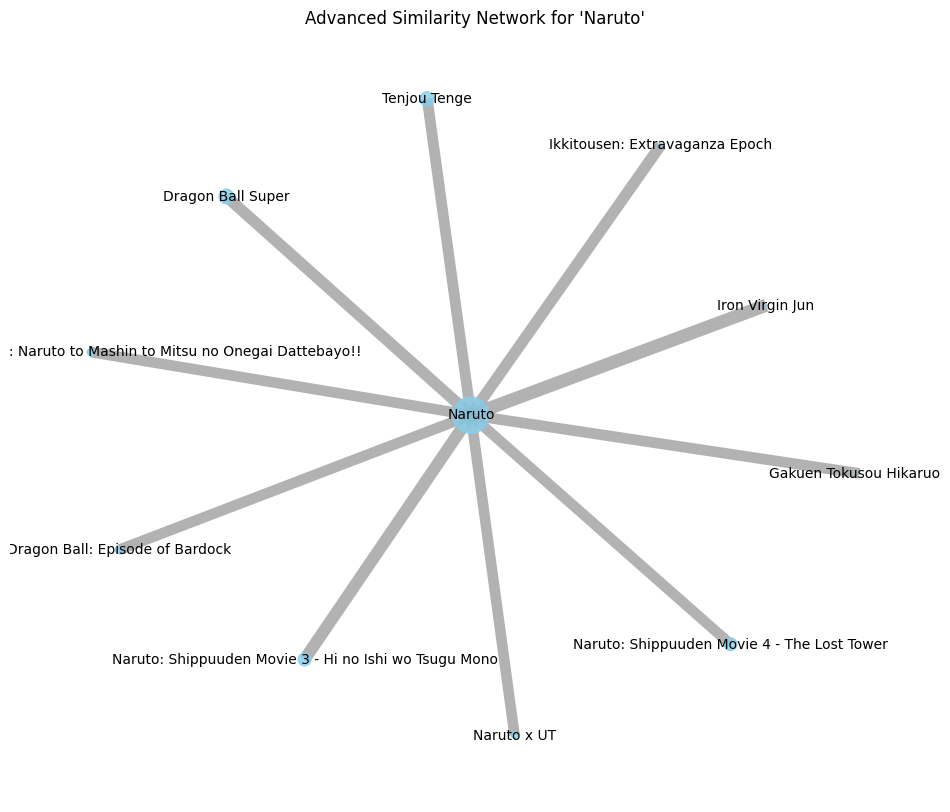

In [21]:
build_advanced_similarity_graph("Naruto", threshold=0.4, top_n=10)
